In [1]:
%load_ext autoreload  
%autoreload 2
import sys, os
sys.path.insert(0,'code/')


# --- CPU/GPU Switch ---
# !! Needs to be set before importing jax !!
USE_GPU = True # Set to False to run on CPU, True to run on GPU (jax-metal)
if USE_GPU:
    os.environ["JAX_PLATFORMS"] = "METAL"
    os.environ["JAX_ENABLE_X64"] = "False"
else:
    os.environ["JAX_PLATFORMS"] = "cpu"
    os.environ["JAX_ENABLE_X64"] = "True"


from time import time
import scipy
import numpy as np
import warnings
import pickle

from matplotlib import pyplot as plt
from ipywidgets import interact, fixed
from astropy.io import fits
from training_PCA_NN import *
import jax
print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())

JAX version: 0.5.0
Metal device set to: Apple M1 Max
JAX devices: [METAL(id=0)]
METAL:0


W0000 00:00:1772014161.561762 93316881 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1772014161.572099 93316881 service.cc:145] XLA service 0x175794c90 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772014161.572108 93316881 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1772014161.573600 93316881 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1772014161.573609 93316881 mps_client.cc:384] XLA backend will use up to 22906109952 bytes on device 0 for SimpleAllocator.


# Template Generation

The generation of a template is not detailed in this notebook. A template is a numpy array that defines the library of spectra to be learned from; its shape should be (number of channels x number of examples), along with the associated physical parameters (number of examples x number of parameters). These spectra should already be convolved by the desired instrumental response (RMF, ARF). 

## /!\ In case of linked parameters
If two or more parameters are to be the **same accross models**, such as a $n_H$ value that should be the same in a thermal and non-thermal model, it is important that these parameters have the same **units**. SUSHI uses normalized units, not the physical units. Two parameters will have the same unit change if their **mean and standard deviation** are the same from one training set to the next (*before training*). 

This can easily be done by using the same selection of values of the parameters for each training set.

If this is not possible for some reason, you will need to manually look at the transform_physpar function (in training_PCA_NN.py) and write a version that ensures your unit changes are consistant. 

# Preparing the training set

In [2]:
#Load the spectra and associated physical parameters 
tempdir="templates/"
myfile="tbabsapec_kT0.8-6_abund5_template_z-0.033+0.033_fullchannels_Chandra_kTz_kT_logTycho2009.fits" ;name='absapec'
f=tempdir+myfile
templ=np.asarray(fits.getdata(f),dtype='float64')
E_template=np.asarray(fits.getdata(f,ext=1),dtype='float64') #Energy channels
z_template=np.asarray(fits.getdata(f,ext=2),dtype='float64') #redshift 
kT_template=np.asarray(fits.getdata(f,ext=3),dtype='float64') #temperature
i_minE=205 #3 keV
i_maxE=580 #8.48 keV

#Put the spectra and parameters in numpy arrays
spectra=np.reshape(np.asarray(fits.getdata(f),dtype='float64'),(1024,100*100))[i_minE:i_maxE,:]
#Make the spectra sum to one
spectra=spectra/(spectra.sum(0))
phys_params=np.zeros((100*100,2))
phys_params[:,0]=kT_template
phys_params[:,1]=z_template



# Training the model

In [3]:
#In this case, we have 10000 samples, 375 spectral channels, and two physical parametrs. 
#thus, the shape of our arrays are: 
phys_params.shape,spectra.shape

((10000, 2), (375, 10000))

## checking the rank

The **rank** is the number of principal components that will be kept after the PCA.
 
More complex spectra with more varying parameters will require a higher rank. Before training, check that the PCA approximation is accurate enough, using the check_rank function.

The input spectra should not be significantly different from the reconstructed spectra (spec_return_from_PCA). To choose an appropriate rank, we plot the mean-squared error of the reconstruction vs the input, and pick the lowest value that has an acceptable MSE. For a more intuitive approach, the spectra can be plotted against the reconstructed spectra. They should be well superposed. 

In [4]:
MSE_rank=[]
rank=np.arange(5,50)
for r in rank:
    spec_PCA,spec_return_from_PCA,MSE=check_rank(spectra,rank=r)
    MSE_rank.append(MSE)

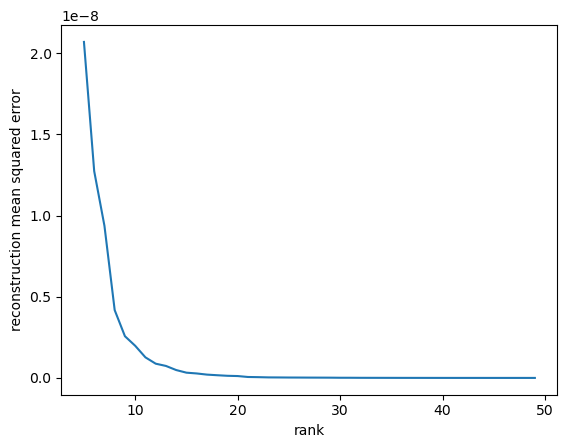

In [5]:
plt.plot(rank,MSE_rank)
plt.xlabel("rank")
plt.ylabel("reconstruction mean squared error")
plt.show()

In [6]:
#Here, it seems that a rank of 30 would be plenty enough for our unit change. 
spec_PCA,spec_return_from_PCA,MSE=check_rank(spectra,rank=30)

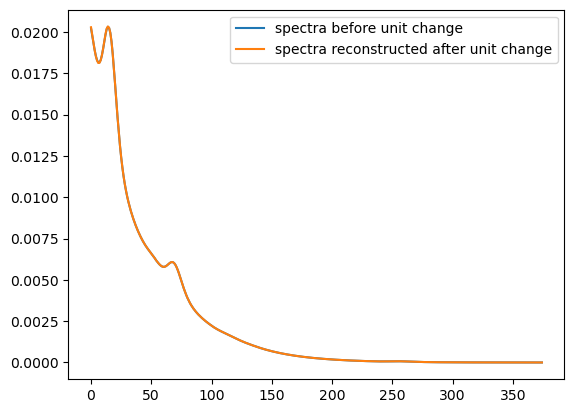

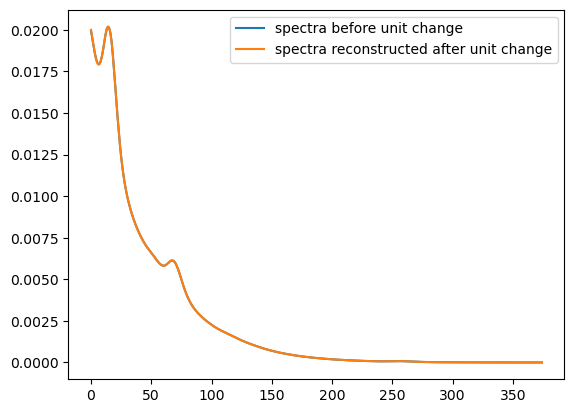

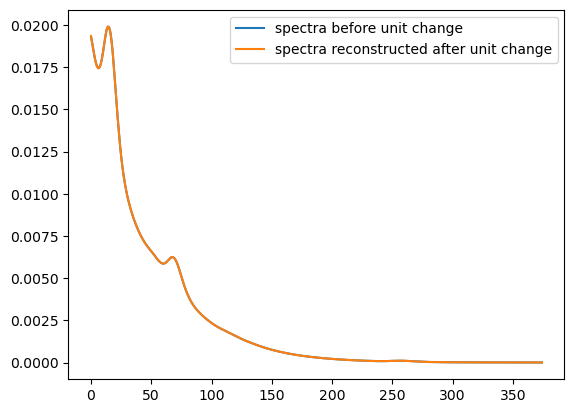

In [7]:
#Checking the reconstruction by eye:
def show_rank_impact(i):
    plt.plot(spectra[:,i],label="spectra before unit change")
    plt.plot(spec_return_from_PCA[:,i],label="spectra reconstructed after unit change")
    plt.legend()
    plt.show()
    
for i in [0,100,300]:
    show_rank_impact(i)

## training

In [8]:
seed=42
batches=int(1e4)
fname="PCA_NN_Chandra_TychoARF"
NN_trained=train_model(phys_params, spectra,rank=30,
	seed_train=seed,seed_split=123,split=0.8,vocal=True,
	batch_size = 500,num_batches = batches,save=True,name=fname)


Transforming data.
Training the network.
First layer shapes:  (2, 256) (256,)
Final layer shapes:  (256, 30) (30,)


Loss= 8.1325e-01, started with: 1.3754e+04: 100%|██████████| 10000/10000 [01:38<00:00, 101.53it/s]

training time for 10000 iterations = 98.5 seconds


In [9]:
print("file saved under:")
print(f'{fname}_batches_{batches}_seed_{seed}.p')

file saved under:
PCA_NN_Chandra_TychoARF_batches_10000_seed_42.p


In [10]:
NN_trained.keys(),NN_trained["train_direc"].keys()
#'loss': cost function over iterations 
#'opt_state': the network weights
#'train_direct': dictionary of parameters that include: 
    #'X_train': the training spectra
    #'X_test': the testing spectra
    #'Y_train': the training parameters
    #'Y_test': the testing parameters
    #'spec_cnst': the unit change constants for the spectra
    #'params_cnst': the unit change constants for the parameters 
        #/!\ if a parameter is to be the same accross two models, this unit change should be the SAME.

(dict_keys(['loss', 'opt_state', 'train_direc']),
 dict_keys(['X_train', 'X_test', 'Y_train', 'Y_test', 'spec_cnst', 'params_cnst']))

Text(0.5, 0, 'iterations')

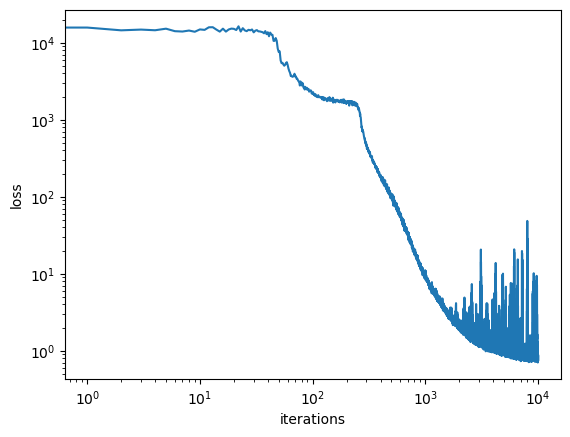

In [11]:
plt.loglog(NN_trained["loss"])
plt.ylabel("loss")
plt.xlabel("iterations")

If the loss function above has converged, great! The network is now trained.  
The network is saved under a pickle file of the name defined above: 
In our case, PCA_NN_Chandra_TychoARF_batches_10000_seed_42.p. 
This file can now be used in the SUSHI tutorial.